In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

import re,time
import string
import nltk

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,f1_score,classification_report,confusion_matrix,ConfusionMatrixDisplay
import warnings
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from tqdm.notebook import tqdm
# -----------------------------
# Load Dataset
# -----------------------------
from pathlib import Path
PROJECT_DIR = (Path.cwd() /'..').resolve()
OUTPUTS_DIR = PROJECT_DIR/ 'outputs'
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
TRAIN_PATH = PROJECT_DIR/ 'data'/ 'train.csv'
TEST_PATH  = PROJECT_DIR/ 'data'/ 'test.csv'
df = pd.read_csv(TRAIN_PATH)

# TASK1:Data Exploration and Visualization

Dataset Shape: (288000, 2)

Columns: Index(['text', 'rating'], dtype='object')

First 5 rows:
                                                 text  rating
0  This place is TERRIBLE; the people in charge a...       2
1  Terrible Service! And they are saying that I n...       1
2  Absolutely terrible company.  They sent me to ...       1
3  To find it, either park in front of the Tuesda...       4
4  Mall location. Used their services for sedan. ...       4

Missing Values:
 text      0
rating    0
dtype: int64
Train shape:(288000, 2) , columns: ['text', 'rating']

Label distribution (%):
rating
1    38.05%
2    11.19%
3    12.27%
4     28.5%
5     10.0%
Name: proportion, dtype: object

First 5 rows:
                                                 text  rating
0  This place is TERRIBLE; the people in charge a...       2
1  Terrible Service! And they are saying that I n...       1
2  Absolutely terrible company.  They sent me to ...       1
3  To find it, either park in front of the Tue

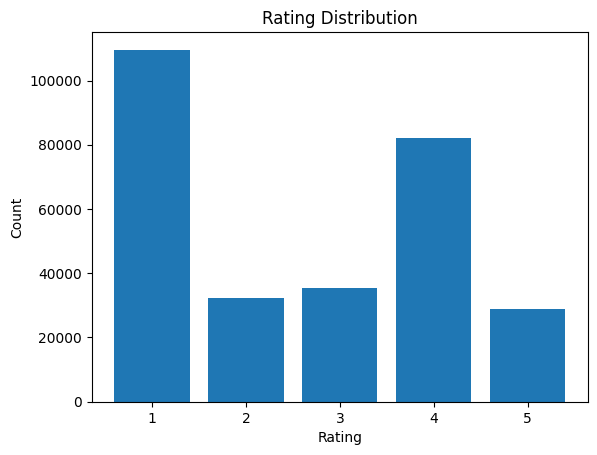


Word Count Summary:
 count    288000.000000
mean         58.695444
std          80.353889
min           1.000000
25%          12.000000
50%          32.000000
75%          72.000000
max        1533.000000
Name: word_count, dtype: float64


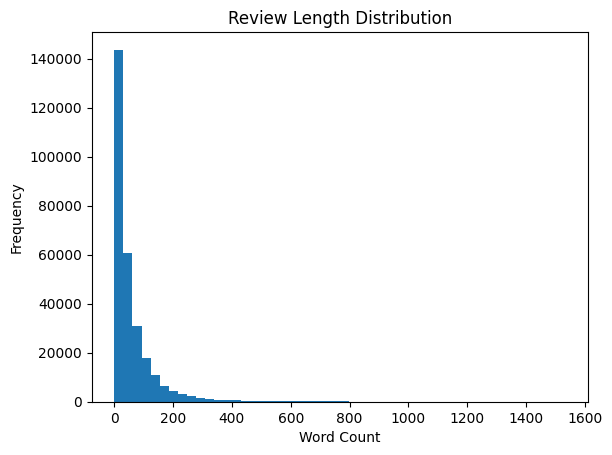


Average Review Length by Rating:
 rating
1    81.615387
2    76.244615
3    46.774868
4    32.712000
5    40.522188
Name: word_count, dtype: float64


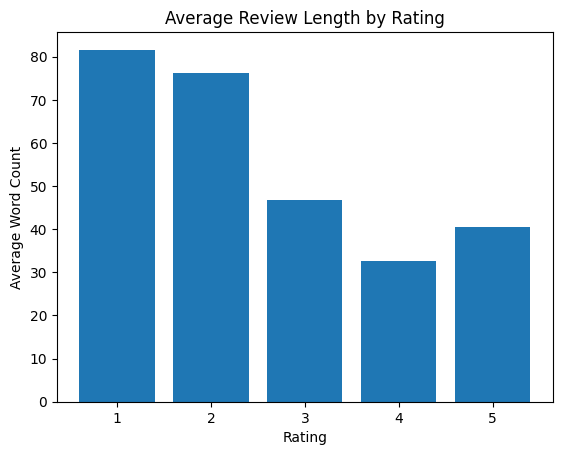


Top 20 Most Common Words:
 [('the', 689895), ('and', 537695), ('to', 513101), ('i', 488694), ('a', 374636), ('was', 239772), ('they', 215527), ('my', 215343), ('for', 201520), ('of', 198805), ('in', 178564), ('is', 176385), ('that', 151184), ('it', 142870), ('not', 141581), ('this', 130130), ('with', 127829), ('have', 122552), ('you', 116858), ('on', 112338)]


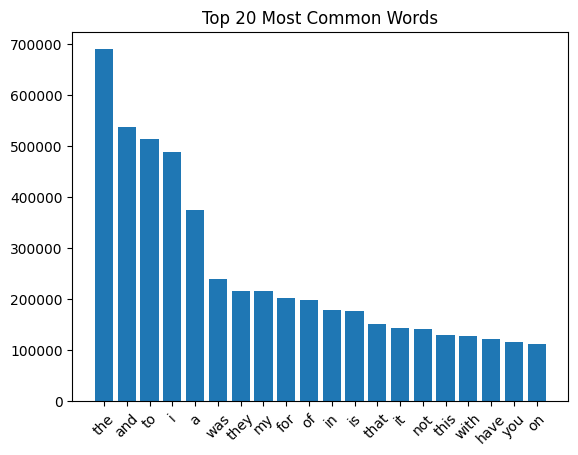

In [3]:
# -----------------------------
# Basic Inspection
# -----------------------------
print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns)
print("\nFirst 5 rows:\n", df.head())

df = df.dropna(subset=['text', 'rating'])
df['text'] = df['text'].astype(str)
df['rating'] = df['rating'].astype(int)

print("\nMissing Values:\n", df.isnull().sum())
print(f"Train shape:{df.shape} , columns: {df.columns.tolist()}")
print("\nLabel distribution (%):")
print((df['rating'].value_counts(normalize=True).sort_index() * 100).round(2).astype(str) + "%")

print("\nFirst 5 rows:\n", df.head())

# -----------------------------
# 4. Rating Distribution
# -----------------------------
rating_counts = df['rating'].value_counts().sort_index()
# print("\nRating Distribution:\n", rating_counts)
plt.bar(rating_counts.index, rating_counts.values)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

# -----------------------------
# 5. Review Length Analysis
# -----------------------------
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

print("\nWord Count Summary:\n", df['word_count'].describe())

plt.hist(df['word_count'], bins=50)
plt.title("Review Length Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

# -----------------------------
# 6. Average Length by Rating
# -----------------------------
avg_length = df.groupby('rating')['word_count'].mean()

print("\nAverage Review Length by Rating:\n", avg_length)

plt.bar(avg_length.index, avg_length.values)
plt.title("Average Review Length by Rating")
plt.xlabel("Rating")
plt.ylabel("Average Word Count")
plt.show()

# -----------------------------
# 7. Most Common Words
# -----------------------------
all_words = " ".join(df['text']).lower().split()
common_words = Counter(all_words).most_common(20)

print("\nTop 20 Most Common Words:\n", common_words)

words = [w for w, c in common_words]
counts = [c for w, c in common_words]

plt.bar(words, counts)
plt.title("Top 20 Most Common Words")
plt.xticks(rotation=45)
plt.show()

# Task2:Text Processing and Normalization: (15%) 

In [4]:
# -----------------------------
# NLP tools
# -----------------------------
nltk.download('stopwords')
nltk.download('wordnet')
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

# -----------------------------
# Preprocessing functions
# -----------------------------
def basic_clean(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    return text

def remove_stopwords_tokens(tokens):
    return [w for w in tokens if w not in stop_words]

def stem_tokens(tokens):
    return [stemmer.stem(w) for w in tokens]

def lemma_tokens(tokens):
    return [lemmatizer.lemmatize(w, pos='v') for w in tokens]

def tokenize(text):
    return text.split()

# -----------------------------
# Apply processing
# -----------------------------
# df['original'] = df['text']
# df['clean'] = df['text'].apply(basic_clean)
# df['nostop'] = df['text'].apply(remove_stopwords)
# df['stem'] = df['text'].apply(stemming)
# df['lemma'] = df['text'].apply(lemmatization)

# def show_memory_usage(df, name="DataFrame"):
#     mem = df.memory_usage(deep=True).sum() / (1024 ** 2)  # MB
#     print(f"\n{name} memory usage: {mem:.2f} MB")

# show_memory_usage(df, "Full dataset")

# print(df[['original', 'clean', 'nostop', 'stem', 'lemma']].head())

# # split data
# X = df['text']
# y = df['rating']

# # train / test split
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y,
#     test_size=0.2,
#     random_state=42,
#     stratify=y
# )

# # Resample the training set to reduce computation
# X_train, _, y_train, _ = train_test_split(
#     X_train, y_train,
#     train_size=0.2,
#     random_state=42,
#     stratify=y_train
# )

#use small data size
df_sample, _ = train_test_split(
    df,
    train_size=30000,
    stratify=df["rating"],
    random_state=42
)

df_sample['original'] = df_sample['text']
df_sample['clean'] = df_sample['text'].apply(basic_clean)
df_sample['tokens'] = df_sample['clean'].apply(tokenize)
df_sample['tokens_nostop'] = df_sample['tokens'].apply(remove_stopwords_tokens)
df_sample['tokens_stem'] = df_sample['tokens_nostop'].apply(stem_tokens)
df_sample['tokens_lemma'] = df_sample['tokens_nostop'].apply(lemma_tokens)

df_sample['nostop'] = df_sample['tokens_nostop'].apply(lambda x: " ".join(x))
df_sample['stem']   = df_sample['tokens_stem'].apply(lambda x: " ".join(x))
df_sample['lemma']  = df_sample['tokens_lemma'].apply(lambda x: " ".join(x))

X = df_sample['text']
y = df_sample['rating']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

train_idx = X_train.index
test_idx = X_test.index

# -----------------------------
# Evaluation function
# -----------------------------
def evaluate(column_name):
    X_train_col = df_sample.loc[train_idx, column_name]
    X_test_col = df_sample.loc[test_idx, column_name]

    y_train_col = df_sample.loc[train_idx, 'rating']
    y_test_col = df_sample.loc[test_idx, 'rating']

    model = Pipeline([
        ('tfidf', TfidfVectorizer()),
        ('clf', LogisticRegression(max_iter=1000))
    ])

    model.fit(X_train_col, y_train_col)
    preds = model.predict(X_test_col)

    acc = accuracy_score(y_test_col, preds)
    f1 = f1_score(y_test_col, preds, average="macro")

    print(f"{column_name} Accuracy: {acc:.4f}, Macro-F1: {f1:.4f}")

    return {
        "method": column_name,
        "accuracy": acc,
        "macro_f1": f1
    }

# -----------------------------
# Compare all methods
# -----------------------------
print("\nModel Performance:")
results = []
results.append(evaluate('original'))
results.append(evaluate('clean'))
results.append(evaluate('nostop'))
results.append(evaluate('stem'))
results.append(evaluate('lemma'))

text_process_results_df = pd.DataFrame(results)

text_process_results_df = text_process_results_df.sort_values(by="macro_f1", ascending=False)

print("\nSorted Results:")
print(text_process_results_df)

best_method = text_process_results_df.iloc[0]["method"]
print(f"\nBest preprocessing method: {best_method}")

output_path = OUTPUTS_DIR / "processed_data.csv"
df_sample.to_csv(output_path, index=False)
print(f"\nSaved processed dataframe to: {output_path}")

results_path = OUTPUTS_DIR / "preprocessing_results.csv"
text_process_results_df.to_csv(results_path, index=False)

print(f"Saved results to: {results_path}")

[nltk_data] Downloading package stopwords to /home/chao/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/chao/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!



Model Performance:
original Accuracy: 0.6425, Macro-F1: 0.4693
clean Accuracy: 0.6417, Macro-F1: 0.4674
nostop Accuracy: 0.6330, Macro-F1: 0.4496
stem Accuracy: 0.6327, Macro-F1: 0.4553
lemma Accuracy: 0.6340, Macro-F1: 0.4519

Sorted Results:
     method  accuracy  macro_f1
0  original  0.642500  0.469271
1     clean  0.641667  0.467416
3      stem  0.632667  0.455306
4     lemma  0.634000  0.451931
2    nostop  0.633000  0.449609

Best preprocessing method: original

Saved processed dataframe to: /home/chao/work/Applied_Text_Analytics_CW2/outputs/processed_data.csv
Saved results to: /home/chao/work/Applied_Text_Analytics_CW2/outputs/preprocessing_results.csv


# TASK3:Vector space Model and feature representation

In [28]:
nltk.download('omw-1.4')

#use the same data as TASK2
X_train = df_sample.loc[train_idx, best_method]
X_val = df_sample.loc[test_idx, best_method]

y_train = df_sample.loc[train_idx, 'rating']
y_val = df_sample.loc[test_idx, 'rating']

# ---------------------------------
# 4. Function to train and evaluate model
# ---------------------------------
results = []

def evaluate_model(model_name, vectorizer):
    model = Pipeline([
        ('vectorizer', vectorizer),
        ('classifier', LogisticRegression(max_iter=1000))
    ])

    model.fit(X_train, y_train)
    predictions = model.predict(X_val)

    accuracy = accuracy_score(y_val, predictions)
    Macro_F1  = f1_score(y_val, predictions, average='macro')

    print(f"\n{'='*60}\nModel: {model_name} | Feature size: {len(model.named_steps['vectorizer'].vocabulary_)} | Acc: {accuracy:.4f} | Macro-F1: {Macro_F1:.4f}")

    results.append({
        'Model': model_name,
        'Accuracy': round(accuracy, 4),
        'Macro_F1 ': round(Macro_F1 , 4),
        'model_obj': model
    })

# ---------------------------------
# 5. Experiment 1: Bag of Words
# ---------------------------------
evaluate_model(
    "Bag of Words - Unigram",
    CountVectorizer(ngram_range=(1,1))
)

evaluate_model(
    "Bag of Words - Unigram + Bigram",
    CountVectorizer(ngram_range=(1,2))
)

evaluate_model(
    "Bag of Words - Unigram + Bigram + Trigram",
    CountVectorizer(ngram_range=(1,3), min_df=2)
)

# ---------------------------------
# 6. Experiment 2: TF-IDF
# ---------------------------------
evaluate_model(
    "TF-IDF - Unigram",
    TfidfVectorizer(ngram_range=(1,1))
)

evaluate_model(
    "TF-IDF - Unigram + Bigram",
    TfidfVectorizer(ngram_range=(1,2))
)

evaluate_model(
    "TF-IDF - Unigram + Bigram + Trigram",
    TfidfVectorizer(ngram_range=(1,3), min_df=2)
)

[nltk_data] Downloading package omw-1.4 to /home/chao/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!



Model: Bag of Words - Unigram | Feature size: 14854 | Acc: 0.6322 | Macro-F1: 0.4055

Model: Bag of Words - Unigram + Bigram | Feature size: 178564 | Acc: 0.6370 | Macro-F1: 0.4134

Model: Bag of Words - Unigram + Bigram + Trigram | Feature size: 43117 | Acc: 0.6293 | Macro-F1: 0.4151

Model: TF-IDF - Unigram | Feature size: 14854 | Acc: 0.6450 | Macro-F1: 0.3979

Model: TF-IDF - Unigram + Bigram | Feature size: 178564 | Acc: 0.6447 | Macro-F1: 0.3788

Model: TF-IDF - Unigram + Bigram + Trigram | Feature size: 43117 | Acc: 0.6452 | Macro-F1: 0.3819


In [29]:
# ---------------------------------
# 7. Show final comparison table
# ---------------------------------
results_df = pd.DataFrame(results)

print("\n" + "="*60)
print("Final Comparison of Feature Representation Methods")
print(results_df.sort_values(by='Macro_F1 ', ascending=False))

best_model = results_df.iloc[0]["model_obj"]
best_model_name = results_df.iloc[0]["Model"]
print("Best model:", best_model_name)

print("\nClassification Report:\n")
preds = best_model.predict(X_val)
print(classification_report(y_val, preds))


Final Comparison of Feature Representation Methods
                                       Model  Accuracy  Macro_F1   \
2  Bag of Words - Unigram + Bigram + Trigram    0.6293     0.4151   
1            Bag of Words - Unigram + Bigram    0.6370     0.4134   
0                     Bag of Words - Unigram    0.6322     0.4055   
3                           TF-IDF - Unigram    0.6450     0.3979   
5        TF-IDF - Unigram + Bigram + Trigram    0.6452     0.3819   
4                  TF-IDF - Unigram + Bigram    0.6447     0.3788   

                                           model_obj  
2  (CountVectorizer(min_df=2, ngram_range=(1, 3))...  
1  (CountVectorizer(ngram_range=(1, 2)), Logistic...  
0  (CountVectorizer(), LogisticRegression(max_ite...  
3  (TfidfVectorizer(), LogisticRegression(max_ite...  
5  (TfidfVectorizer(min_df=2, ngram_range=(1, 3))...  
4  (TfidfVectorizer(ngram_range=(1, 2)), Logistic...  
Best model: Bag of Words - Unigram

Classification Report:

              preci

# TASK 4: Model Training, Selection and Evaluation

## Text Processing and Normalization
Based on the results of Task 2, the original text achieved the best performance. However, the original version showed comparable results with only a marginal decrease in Macro-F1. 

Therefore, instead of selecting only the best-performing option, both the original and cleaned text representations were retained for further experimentation in Task 4. This allows us to evaluate whether slight normalization can improve model performance when combined with different classifiers.

## Vector Space Model and Feature Representation
Based on the results of Task 3, Bag-of-Words with unigram and bigram features achieved the highest Macro-F1 score, while the inclusion of trigrams provided similar but slightly lower performance.

In Task 4, both unigram+bigram and unigram+bigram+trigram configurations are explored. This enables us to examine whether more complex n-gram features may benefit certain models despite the increased sparsity.

Additionally, TF-IDF is included as a comparison representation to evaluate whether term weighting can improve classification performance over raw frequency-based features.

In [ ]:
warnings.filterwarnings("ignore", category=UserWarning)

# =========================================================
# 1. Reuse Task2 data
# =========================================================
top2_methods = text_process_results_df["method"].head(2).tolist()
print("Top 2 preprocessing methods:", top2_methods)

text_versions = {}

for method in top2_methods:
    text_versions[method] = {
        "X_train": df_sample.loc[train_idx, method],
        "X_test": df_sample.loc[test_idx, method]
    }

y_train = df_sample.loc[train_idx, "rating"]
y_test = df_sample.loc[test_idx, "rating"]

print("Data split summary:")
for text_name, data in text_versions.items():
    print(f"{text_name} -> train: {data['X_train'].shape}, test: {data['X_test'].shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test : {y_test.shape}")


# =========================================================
# 2. Fixed feature representations from Task3
# =========================================================
bow_12_feature = {
    "name": "BoW_(1,2)",
    "vectorizer": CountVectorizer(ngram_range=(1, 2))
}

bow_13_feature = {
    "name": "BoW_(1,3)_min_df2",
    "vectorizer": CountVectorizer(ngram_range=(1, 3), min_df=2)
}

tfidf_11_feature = {
    "name": "TFIDF_(1,1)",
    "vectorizer": TfidfVectorizer(ngram_range=(1, 1))
}

feature_configs = [
    bow_12_feature,
    bow_13_feature,
    tfidf_11_feature
]


# =========================================================
# 3. Model configs
# =========================================================
nb_model_config = {
    "name": "MultinomialNB",
    "classifier": MultinomialNB(),
    "param_grid": {
        "classifier__alpha": [0.1, 0.5, 1.0]
    }
}

lr_model_config = {
    "name": "LogisticRegression",
    "classifier": LogisticRegression(max_iter=3000, random_state=42),
    "param_grid": {
        "classifier__C": [0.1, 1.0, 10.0],
        "classifier__class_weight": [None, "balanced"]
    }
}

svm_model_config = {
    "name": "LinearSVC",
    "classifier": LinearSVC(max_iter=5000),
    "param_grid": {
        "classifier__C": [0.1, 1.0, 10.0],
        "classifier__class_weight": [None, "balanced"]
    }
}

model_configs = [
    nb_model_config,
    lr_model_config,
    svm_model_config
]


# =========================================================
# 4. Helper functions
# =========================================================
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def run_grid_search(X_train, y_train, vectorizer, classifier, param_grid):
    pipeline = Pipeline([
        ("vectorizer", vectorizer),
        ("classifier", classifier)
    ])

    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring="f1_macro",
        cv=cv_strategy,
        n_jobs=-1,
        verbose=0,
        refit=True
    )
    grid.fit(X_train, y_train)
    return grid


def evaluate_best_model(best_model, X_test, y_test):
    y_pred = best_model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    weighted_f1 = f1_score(y_test, y_pred, average="weighted")
    vocab_size = len(best_model.named_steps["vectorizer"].vocabulary_)

    return {
        "Feature_Size": vocab_size,
        "Test_Accuracy": acc,
        "Test_Macro_F1": macro_f1,
        "Test_Weighted_F1": weighted_f1
    }


def save_cv_results(grid, exp_id, exp_name):
    cv_df = pd.DataFrame(grid.cv_results_)[
        ["mean_test_score", "std_test_score", "rank_test_score", "params"]
    ].sort_values(by="rank_test_score")

    cv_df.insert(0, "Experiment_ID", exp_id)
    cv_df.insert(1, "Experiment", exp_name)

    output_path = OUTPUTS_DIR / f"task4_{exp_id:02d}_cv_results.csv"
    cv_df.to_csv(output_path, index=False)
    return output_path


def plot_confusion_matrix_for_model(model, X_test, y_test, title):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred, labels=sorted(y_test.unique()))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=sorted(y_test.unique())
    )
    disp.plot()
    plt.title(title)
    plt.show()

    print("\nClassification report:")
    print(classification_report(y_test, y_pred, digits=4))


# =========================================================
# 5. Build experiment list
# =========================================================
experiments = []

exp_id = 1
for text_name, text_data in text_versions.items():
    for feature_config in feature_configs:
        for model_config in model_configs:
            experiments.append({
                "exp_id": exp_id,
                "text_name": text_name,
                "text_data": text_data,
                "feature_config": feature_config,
                "model_config": model_config
            })
            exp_id += 1

print(f"\nTotal experiments: {len(experiments)}")


# =========================================================
# 6. Run all experiments
# =========================================================
all_grids = {}
all_results = []

pbar = tqdm(experiments, total=len(experiments), desc="Task4 Experiments")

for exp in pbar:
    exp_id = exp["exp_id"]
    text_name = exp["text_name"]
    text_data = exp["text_data"]
    feature_config = exp["feature_config"]
    model_config = exp["model_config"]

    X_train_current = text_data["X_train"]
    X_test_current = text_data["X_test"]

    feature_name = feature_config["name"]
    vectorizer = feature_config["vectorizer"]

    model_name = model_config["name"]
    classifier = model_config["classifier"]
    param_grid = model_config["param_grid"]

    exp_name = f"{text_name} + {feature_name} + {model_name}"

    pbar.set_postfix({
        "text": text_name,
        "feature": feature_name,
        "model": model_name
    })

    start_time = time.time()

    grid = run_grid_search(
        X_train=X_train_current,
        y_train=y_train,
        vectorizer=vectorizer,
        classifier=classifier,
        param_grid=param_grid
    )

    elapsed = time.time() - start_time

    all_grids[exp_name] = {
        "grid": grid,
        "X_test": X_test_current,
        "y_test": y_test
    }

    cv_path = save_cv_results(grid, exp_id, exp_name)

    test_metrics = evaluate_best_model(
        best_model=grid.best_estimator_,
        X_test=X_test_current,
        y_test=y_test
    )

    all_results.append({
        "Experiment_ID": exp_id,
        "Experiment": exp_name,
        "Text": text_name,
        "Feature": feature_name,
        "Model": model_name,
        "Best_Params": str(grid.best_params_),
        "CV_Macro_F1": grid.best_score_,
        "CV_Results_File": str(cv_path),
        "Run_Time_Seconds": elapsed,
        **test_metrics
    })


# =========================================================
# 7. Final comparison
# =========================================================
results_df = pd.DataFrame(all_results).sort_values(
    by="Test_Macro_F1",
    ascending=False
).reset_index(drop=True)

print("\nFinal comparison on test set:")
display(results_df)

results_path = OUTPUTS_DIR / "task4_all_combinations_comparison.csv"
results_df.to_csv(results_path, index=False)
print(f"\nSaved final comparison to: {results_path}")


# =========================================================
# 8. Best experiment details
# =========================================================
best_row = results_df.iloc[0]
best_exp_name = best_row["Experiment"]
best_grid_info = all_grids[best_exp_name]
best_grid = best_grid_info["grid"]

print(f"\nBest experiment on test set: {best_exp_name}")
print(f"Best parameters: {best_grid.best_params_}")
print(f"Best CV Macro-F1: {best_grid.best_score_:.4f}")
print(f"Best Test Macro-F1: {best_row['Test_Macro_F1']:.4f}")


# =========================================================
# 9. Plot top results
# =========================================================
top_n = 10
plot_df = results_df.head(top_n)

plt.figure(figsize=(12, 6))
plt.bar(plot_df["Experiment"], plot_df["Test_Macro_F1"])
plt.ylabel("Test Macro F1")
plt.title(f"Top {top_n} Task 4 Experiments")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()


# =========================================================
# 10. Confusion matrix for the best experiment only
# =========================================================
plot_confusion_matrix_for_model(
    model=best_grid.best_estimator_,
    X_test=best_grid_info["X_test"],
    y_test=best_grid_info["y_test"],
    title=f"Confusion Matrix - {best_exp_name}"
)

Top 2 preprocessing methods: ['stem', 'original']
Data split summary:
stem -> train: (24000,), test: (6000,)
original -> train: (24000,), test: (6000,)
y_train: (24000,)
y_test : (6000,)

Total experiments: 18


Task4 Experiments:   0%|          | 0/18 [00:00<?, ?it/s]

# Analyze
The best performance was achieved using the original text with a Bag-of-Words representation (1–3 grams) and Logistic Regression, reaching a macro-F1 of 0.5246. Overall, Bag-of-Words outperformed TF-IDF, and Logistic Regression consistently performed better than SVM and Naive Bayes. However, performance on minority classes remained weaker, indicating the impact of class imbalance.